In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
import pandas as pd

import warnings


warnings.filterwarnings('ignore')

In [5]:
data=pd.read_csv('StudentsPerformance.csv')



In [6]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
data.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.shape

(1000, 8)

In [10]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
data.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [12]:
print(data["gender"].unique())

['female' 'male']


In [13]:
data.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [15]:
data.isna().sum()  

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [17]:
data.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [18]:
print("Categories in gender column:", end=" ")
print(data["gender"].unique() )

Categories in gender column: ['female' 'male']


In [19]:
print("categories in   race/ethnicity column:", end=" ")
print(data["race/ethnicity"].unique() )

categories in   race/ethnicity column: ['group B' 'group C' 'group A' 'group D' 'group E']


In [21]:
print("categories in   test prepartion  column:", end=" ")
print(data["test preparation course"].unique() )

categories in   test prepartion  column: ['none' 'completed']


In [22]:
print("categories in  math score:", end=" ")
print(data["math score"].unique() )

categories in  math score: [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]


In [23]:
print("categories in  reading score:", end=" ")
print(data["reading score"].unique() )

categories in  reading score: [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]


In [24]:
print("categories in  writing score:", end=" ")
print(data["writing score"].unique() )

categories in  writing score: [ 74  88  93  44  75  78  92  39  67  50  52  43  73  70  58  86  28  46
  61  63  53  80  72  55  65  38  82  79  83  59  57  54  68  66  62  76
  48  42  87  49  10  34  71  37  56  41  22  81  45  36  89  47  90 100
  64  98  51  40  84  69  33  60  85  91  77  27  94  95  19  35  32  96
  97  99  15  30  23]


In [28]:
data['Total score'] = data['math score'] + data['reading score'] + data['writing score']
data[['math score', 'reading score', 'writing score', 'Total score']].head()

,math score,reading score,writing score,Total score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [31]:
data["Average score"] = data["Total score"] / 3
data[["math score", "reading score", "writing score", "Total score", "Average score"]].head()


,math score,reading score,writing score,Total score,Average score
0,72,72,74,218,72.666667
1,69,90,88,247,82.333333
2,90,95,93,278,92.666667
3,47,57,44,148,49.333333
4,76,78,75,229,76.333333


In [34]:
Numeric_features=[feature for feature in data.columns if data[feature].dtype!='O']
Catagorical_features=[feature for feature in data.columns if data[feature].dtype=='O']

print('we have {} numerical features : {}'.format(len(Numeric_features),Numeric_features))
print('we have {} catagorical features: {}'.format(len(Catagorical_features),Catagorical_features))

we have 5 numerical features : ['math score', 'reading score', 'writing score', 'Total score', 'Average score']
we have 5 catagorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


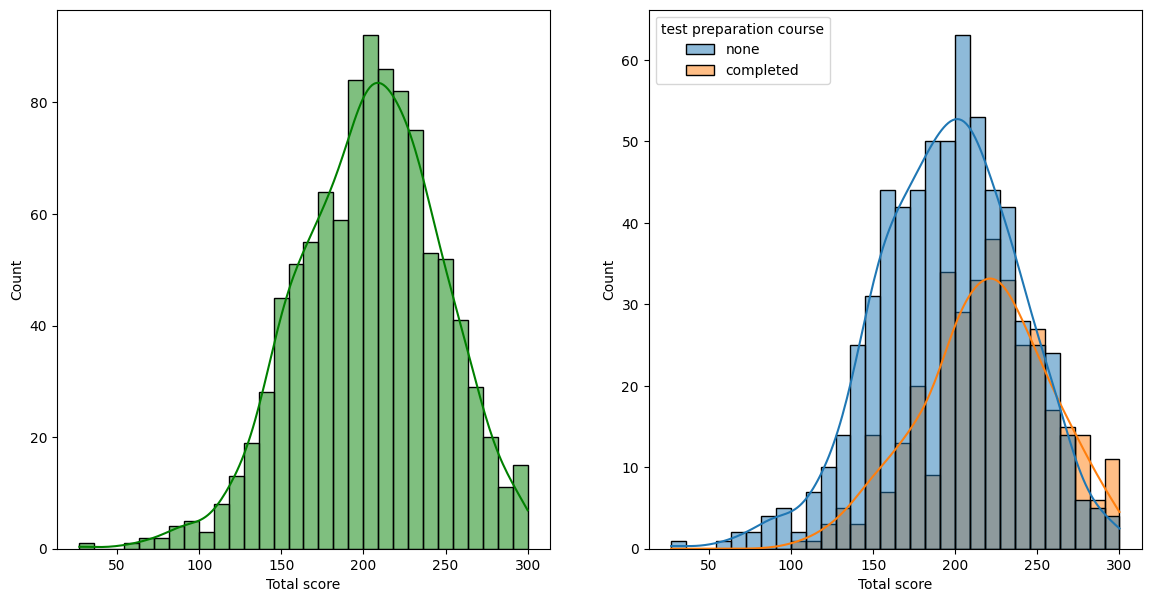

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

plt.subplot(121)
sns.histplot(data=data, x='Total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Total score', bins=30, kde=True, hue='test preparation course')

plt.show()

In [42]:
reading_full = data[data['reading score'] == 100]['Average score'].count()
print(reading_full)

writing_full = data[data['writing score'] == 100]['Average score'].count()
print(writing_full)

math_full = data[data['math score'] == 100]['Average score'].count()
print(math_full)

print(f'Number of Students with full marks in reading score: {reading_full}')
print(f'Number of Students with full marks in writing score: {writing_full}')
print(f'Number of Students with full marks in maths: {math_full}')

17
14
7
Number of Students with full marks in reading score: 17
Number of Students with full marks in writing score: 14
Number of Students with full marks in maths: 7


In [39]:
reading_less_20 = data[data['reading score'] <= 20]['Average score'].count()
print(f'Number of students with less than 20 marks in reading: {reading_less_20}')

writing_less_20 = data[data['writing score'] <= 20]['Average score'].count()
print(f'Number of students with less than 20 marks in writing: {writing_less_20}')

maths_less_20 = data[data['math score'] <= 20]['Average score'].count()
print(f'Number of students with less than 20 marks in maths: {maths_less_20}')

Number of students with less than 20 marks in reading: 1
Number of students with less than 20 marks in writing: 3
Number of students with less than 20 marks in maths: 4


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Total score                  1000 non-null   int64  
 9   Average score                1000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


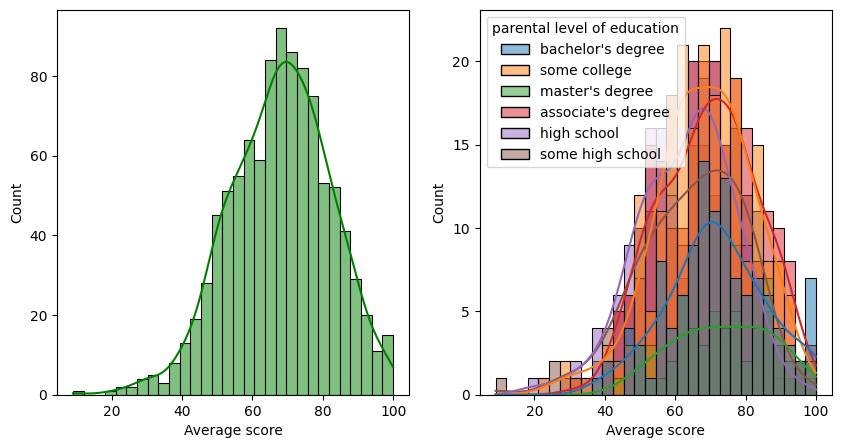

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Average score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Average score', bins=30, kde=True, hue='parental level of education')

plt.show()

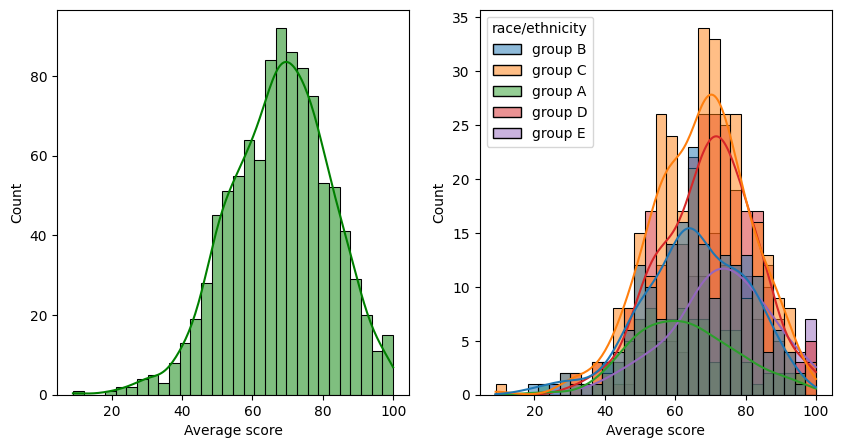

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Average score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Average score', bins=30, kde=True, hue='race/ethnicity')

plt.show()

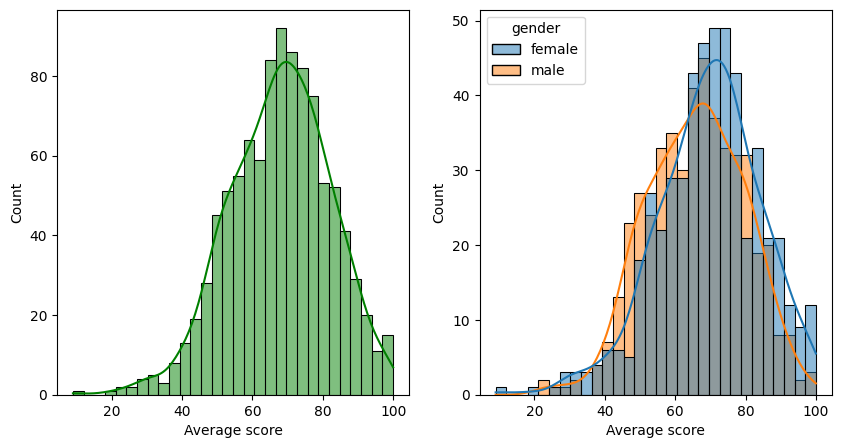

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Average score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Average score', bins=30, kde=True, hue='gender')

plt.show()

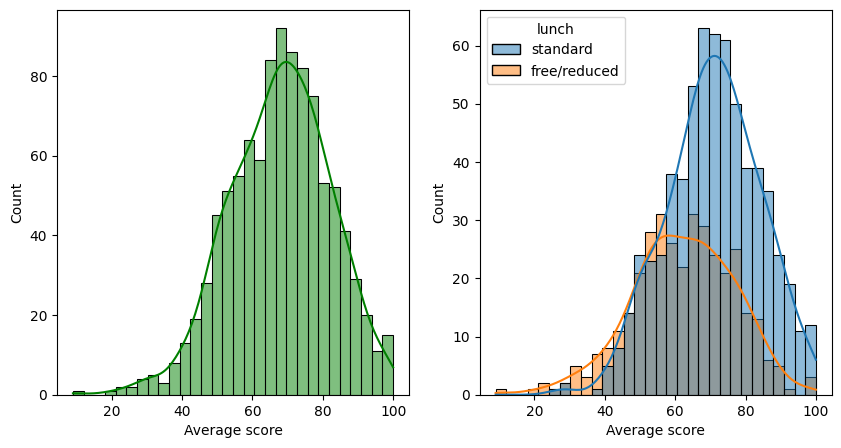

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Average score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Average score', bins=30, kde=True, hue='lunch')

plt.show()

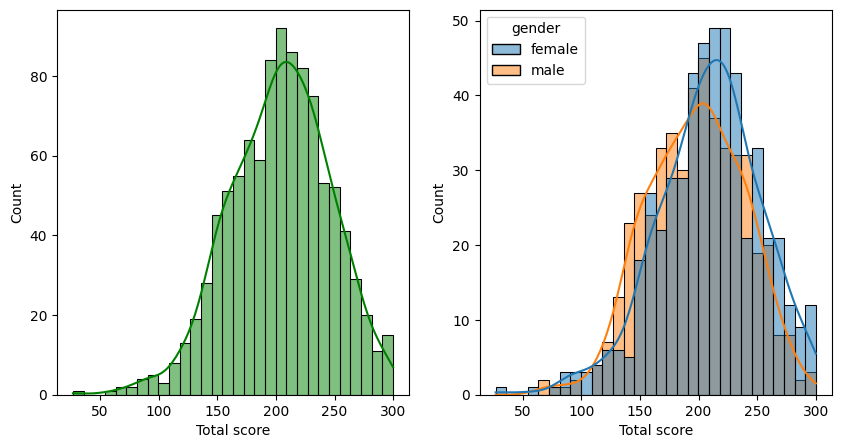

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Total score', bins=30, kde=True, hue='gender')

plt.show()

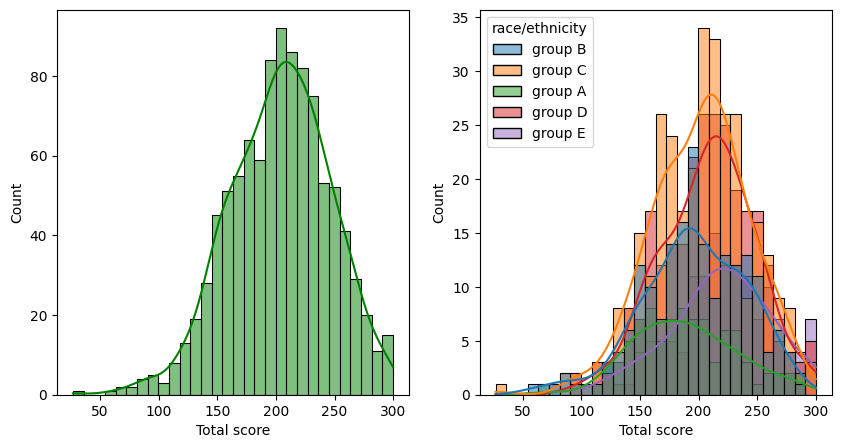

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Total score', bins=30, kde=True, hue='race/ethnicity')

plt.show()

In [56]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Total score                  1000 non-null   int64  
 9   Average score                1000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


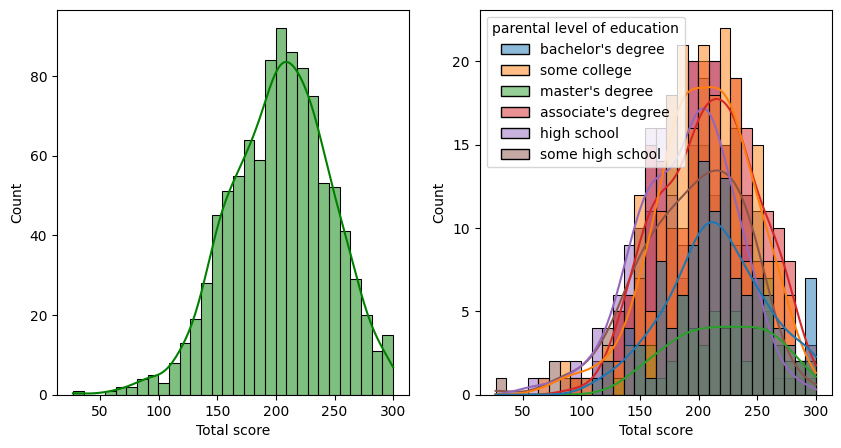

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Total score', bins=30, kde=True, hue='parental level of education')

plt.show()

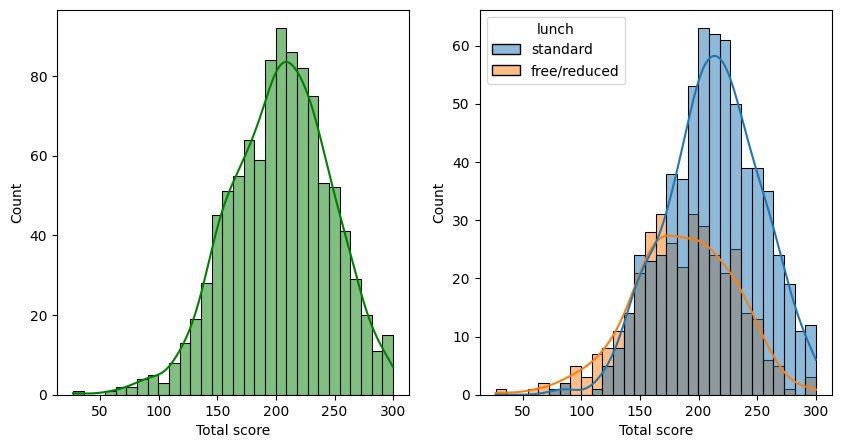

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Total score', bins=30, kde=True, hue='lunch')

plt.show()

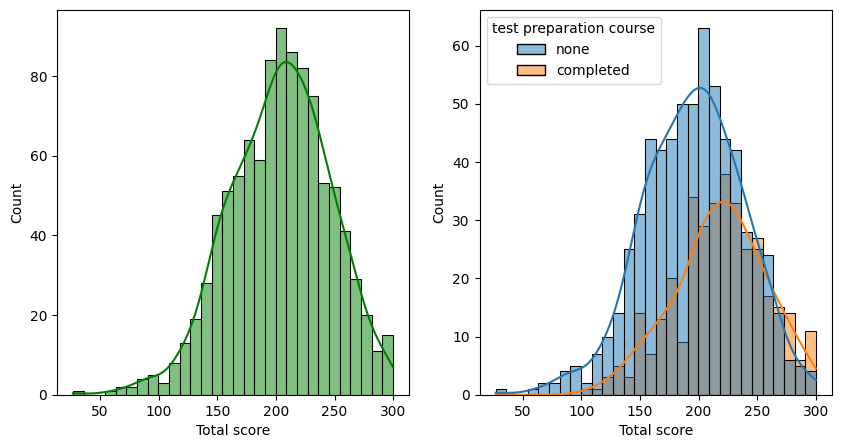

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


plt.subplot(121)
sns.histplot(data=data, x='Total score', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=data, x='Total score', bins=30, kde=True, hue='test preparation course')

plt.show()

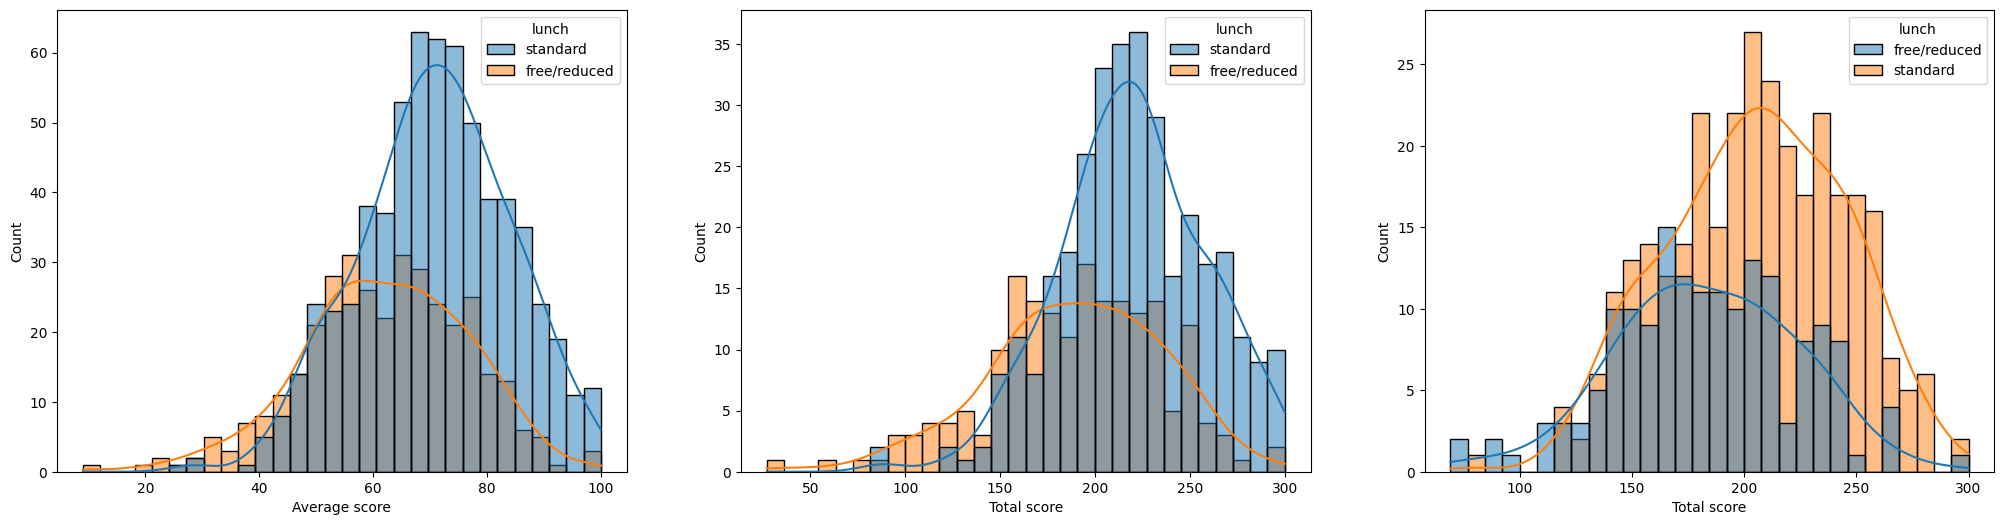

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=data, x='Average score', bins=30, kde=True, hue='lunch', ax=axs[0])


sns.histplot(data=data[data.gender=='female'], x='Total score', bins=30, kde=True, hue='lunch', color='g', ax=axs[1])


sns.histplot(data=data[data.gender=='male'], x='Total score', bins=30, kde=True, color='g', hue='lunch', ax=axs[2])

plt.show()